In [5]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb')
library(data.table)
library(ggplot2)

In [14]:
d1 <- fread("data/phenotypes/filtered_phenotypes_cts.tsv")

In [8]:
d2 <- fread("data/phenotypes/spiros_brava_phenotypes_binary_200k.tsv.gz")

In [15]:
d2 <- d2[,1:4]

In [37]:
d <- merge(d1, d2)
colnames(d)

[1] "eid"                                  
  [2] "sex"                                  
  [3] "age"                                  
  [4] "ukbb.centre"                          
  [5] "Alanine_aminotransferase"             
  [6] "Albumin"                              
  [7] "Alkaline_Phosphatase"                 
  [8] "Apolipoprotein_A"                     
  [9] "Apolipoprotein_B"                     
 [10] "Aspartate_aminotransferase"           
 [11] "C_reactive_Protein"                   
 [12] "Calcium"                              
 [13] "Cholesterol"                          
 [14] "Creatinine_Serum"                     
 [15] "Creatinine_Urine"                     
 [16] "Cystatin_C_Serum"                     
 [17] "Direct_Bilirubin"                     
 [18] "Gamma_glutamyltransferase"            
 [19] "Glucose"                              
 [20] "HbA1c"                                
 [21] "HDL_Cholesterol"                      
 [22] "IGF_1"                                
 [23] "Lipoprotein_A"                        
 [24] "Microalbumin_Urine"                   
 [25] "Oestradiol"                           
 [26] "Phosphate"                            
 [27] "Potassium_Urine"                      
 [28] "Rheumatoid_factor"                    
 [29] "SHBG"                                 
 [30] "Sodium_Urine"                         
 [31] "Testosterone"                         
 [32] "Total_Bilirubin"                      
 [33] "Total_Protein"                        
 [34] "Triglyceride"                         
 [35] "Urate"                                
 [36] "Urea"                                 
 [37] "Vitamin_D"                            
 [38] "Alanine_aminotransferase_residual"    
 [39] "Albumin_residual"                     
 [40] "Alkaline_Phosphatase_residual"        
 [41] "Apolipoprotein_A_residual"            
 [42] "Apolipoprotein_B_residual"            
 [43] "Aspartate_aminotransferase_residual"  
 [44] "C_reactive_Protein_residual"          
 [45] "Calcium_residual"                     
 [46] "Cholesterol_residual"                 
 [47] "Creatinine_Serum_residual"            
 [48] "Creatinine_Urine_residual"            
 [49] "Cystatin_C_Serum_residual"            
 [50] "Direct_Bilirubin_residual"            
 [51] "Gamma_glutamyltransferase_residual"   
 [52] "Glucose_residual"                     
 [53] "HbA1c_residual"                       
 [54] "HDL_Cholesterol_residual"             
 [55] "IGF_1_residual"                       
 [56] "Lipoprotein_A_residual"               
 [57] "Microalbumin_Urine_residual"          
 [58] "Oestradiol_residual"                  
 [59] "Phosphate_residual"                   
 [60] "Potassium_Urine_residual"             
 [61] "Rheumatoid_factor_residual"           
 [62] "SHBG_residual"                        
 [63] "Sodium_Urine_residual"                
 [64] "Testosterone_residual"                
 [65] "Total_Bilirubin_residual"             
 [66] "Total_Protein_residual"               
 [67] "Triglyceride_residual"                
 [68] "Urate_residual"                       
 [69] "Urea_residual"                        
 [70] "Vitamin_D_residual"                   
 [71] "Alanine_aminotransferase_M_residual"  
 [72] "Albumin_M_residual"                   
 [73] "Alkaline_Phosphatase_M_residual"      
 [74] "Apolipoprotein_A_M_residual"          
 [75] "Apolipoprotein_B_M_residual"          
 [76] "Aspartate_aminotransferase_M_residual"
 [77] "C_reactive_Protein_M_residual"        
 [78] "Calcium_M_residual"                   
 [79] "Cholesterol_M_residual"               
 [80] "Creatinine_Serum_M_residual"          
 [81] "Creatinine_Urine_M_residual"          
 [82] "Cystatin_C_Serum_M_residual"          
 [83] "Direct_Bilirubin_M_residual"          
 [84] "Gamma_glutamyltransferase_M_residual" 
 [85] "Glucose_M_residual"                   
 [86] "HbA1c_M_residual"                     
 [87] "HDL_Cholesterol_M_residual"           


In [24]:
d$sex <- factor(d$sex)

In [ ]:
lm(Alanine_aminotransferase	 ~ sex + age, )

Warning message:
"Removed 3225 rows containing non-finite values (stat_density)."


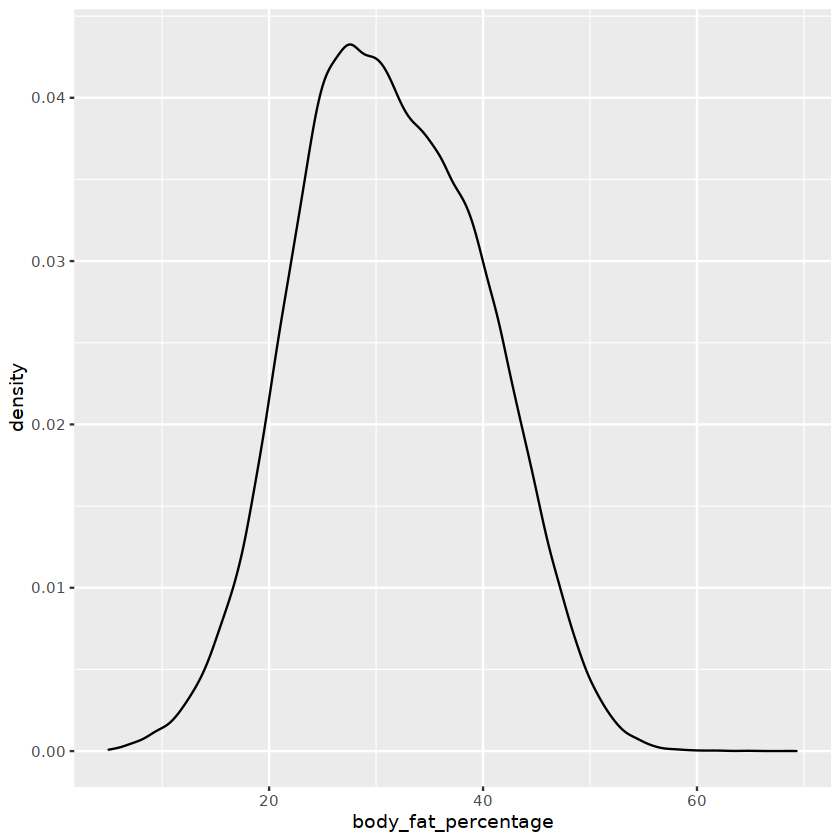

In [35]:
ggplot(d, aes(x=body_fat_percentage, fill = ukbb.centre)) +
    geom_density(alpha = 0.7)

In [59]:
get_fam_file <- function(app_id=11867){
    directory <- "/well/lindgren/UKBIOBANK/nbaya/resources"
    file <- paste0("ukb",app_id,"_pedigree.fam")
    path <- file.path(directory, file)
    if (!file.exists(path)) stop(paste(file, "does not exist!"))
    return(path)
}

get_fam <- function(app_id=11867, related_only = FALSE, trio_only=FALSE){
    path <- get_fam_file(app_id)
    fam <- fread(path)
    paternal_bool <- fam$PAT != 0
    maternal_bool <- fam$MAT != 0
    fam$trio <- paternal_bool & maternal_bool 
    fam$related <- paternal_bool | maternal_bool
    if (related_only){
        fam <- fam[fam$related, ]
    }
    if (trio_only){
        fam <- fam[fam$trio, ]
    }
    fam$FID <- as.character(fam$FID)
    fam$IID <- as.character(fam$IID)
    fam$PAT <- as.character(fam$PAT)
    fam$MAT <- as.character(fam$MAT)
    return(fam)
}

fread_vcf <- function(path){
    stopifnot(file.exists(path))
    command <- paste('zcat ', path, '| grep -v "##"')
    vcf <- fread(cmd=command, sep = '\t')
    return(vcf)
    #cols <- colnames(vcf)
    #final_id_col <- suppressWarnings(max(which(is.na(as.numeric(colnames(vcf))))))
    #metadata <- vcf[,1:final_id_col]
    #genotypes <- vcf[,(final_id_col+1):ncol(vcf)]
    #return(list(metadata=metadata, genotypes=genotypes))
}

extract_info_field <- function(info, field){
    return(as.numeric(gsub(paste0(field,"\\="),"",stringr::str_extract(info, paste0(field,'=[0-9]+')))))
}

In [53]:
ped <- get_fam(related_only=TRUE)

In [61]:
path <- "data/phased/wes_union_calls/200k/shapeit5/trios/ukb_wes_union_calls_200k_trios_chr21.vcf.bgz"
#path <- "data/phased/wes_union_calls/200k/shapeit5/parents_improved/ukb_wes_union_calls_200k_shapeit5_parents_chr21.vcf.gz"

In [62]:
fread_vcf(path)

Warning message in fread(cmd = command, sep = "\t"):
"Discarded single-line footer: <<chr21	10413798	21:10413798:G:A	G	A	-10.00	.	AF=0.000175631;AC=70;AN=398564;NS=199282;AC_Hom=0;AC_Het=70;AC_Hemi=0;MAF=0.000175631;HWE=1.00000;ExcHet=0.993958	GT:PP	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0:1.00000	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	>>"


#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,1337856,⋯,2018124,2952983,4943566,4766047,1092396,4890985,4543649,2565996,4906503,3489630
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
chr21,10413783,21:10413783:A:G,A,G,-10,.,AF=0.999400;AC=398325;AN=398564;NS=199282;AC_Hom=398094;AC_Het=231;AC_Hemi=0;MAF=0.000599653;HWE=9.25367e-07;ExcHet=1.00000,GT:PP,1|1,⋯,./.,./.,./.,./.,./.,./.,./.,./.,./.,./.


In [52]:
lst <- fread_vcf(path)
gt <- lst$genotypes
meta <- lst$metadata

Warning message in fread(cmd = command, showProgress = TRUE, sep = "\t"):
"Discarded single-line footer: <<chr21	10413798	21:10413798:G:A	G	A	-10.00	.	AF=0.000175631;AC=70;AN=398564;NS=199282;AC_Hom=0;AC_Het=70;AC_Hemi=0;MAF=0.000175631;HWE=1.00000;ExcHet=0.993958	GT:PP	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0:1.00000	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	>>"


In [40]:
gt

Warning message in cbind(parts$left, ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"
Warning message in cbind(parts$left, ellip_h, parts$right, deparse.level = 0L):
"number of rows of result is not a multiple of vector length (arg 2)"


1337856,3317068,1197384,2740242,1032441,4776767,4086543,2369662,3272542,5867878,⋯,2817542,3734173,3753201,2147138,4316826,1360841,5757493,5578844,2135040,59
<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [22]:
meta$AC <- extract_info_field(meta$INFO, "AC")
meta$AN <- extract_info_field(meta$INFO, "AN")
meta$MAC <- apply(data.table(meta$AC, meta$AN-meta$AC), 1, min)
meta$INFO <- NULL

In [ ]:
sum(ped$MAT %in% colnames(gt))
sum(ped$PAT %in% colnames(gt))
sum(ped$IID %in% colnames(gt))

In [ ]:
riid <- colnames(gt) %in% ped$IID
rpid <- colnames(gt) %in% ped$PAT
rmid <- colnames(gt) %in% ped$MAT
rrows <- rbind(riid, rpid, rmid)
table(colSums(rrows))

In [196]:
# subset columns so that only trios in PED file is retained
cols_keep <- as.logical(colSums(rrows==3))
keep <- sum(cols_keep)
total <- length(cols_keep)
print(paste(keep, "/", total, "samples kept."))
gt <- gt[,cols_keep, with = FALSE]

[1] "0 / 2028 samples kept."


In [186]:
# any singletons?
trio <- ped[2,]
trio
iid <- trio$IID
mat <- trio$MAT
pat <- trio$PAT


FID,IID,PAT,MAT,SEX,PHEN,trio,related
<int>,<int>,<int>,<int>,<int>,<int>,<lgl>,<lgl>
327,2137986,3198027,1536567,2,0,TRUE,TRUE


In [185]:
gt[,colnames(gt) %in% c(iid, mat, pat), with = FALSE]

3198027,1536567
<chr>,<chr>
./.,./.
./.,./.
./.,./.
1/1,1/1
./.,./.
0/0,0/0
./.,./.
./.,./.
./.,./.


In [5]:
gettextf("hello {s}", "f")

Warning message in sprintf(gettext(fmt, domain = domain), ...):
"one argument not used by format 'hello {s}'"


[1] "hello {s}"

In [8]:
?gettextf

Warning message in seq_len(head.end.idx):
"first element used of 'length.out' argument"
ERROR while rich displaying an object: Error in seq_len(head.end.idx): argument must be coercible to non-negative integer

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_conte

In [2]:
format_from_hail <- function(x) gsub('(\\[)|(\\])|(")|(\\})|(\\{)','',x)

fread_ko <- function(f, samples, labels){

    # read file and
    d <- fread(f)
    d <- d[,c(2,1,4,9,10), with = FALSE]
    d <- d[d$s %in% samples]
    d$varid <- format_from_hail(d$varid)

    # set consequence
    d$csqs <- labels[d$knockout]
    d$knockout <- NULL

    # get unique genes and samples
    in_genes <- unique(d$gene_id)
    in_samples <- unique(d$s)
    out_samples <- samples[!samples %in% in_samples]

    # generate grid of out samples and genes to
    # ensure that every sample has the gene used
    grid <- expand.grid(out_samples, in_genes)
    colnames(grid) <- c("s","gene_id")

    # combine the data without duplicating a sample-gene pair
    new_grid <- rbind(d[,c(1,2)], grid[,c(1,2)])
    new_grid <- new_grid[!duplicated(new_grid),]
    stopifnot(nrow(new_grid)-nrow(grid)==nrow(d))
    new_grid$varid <- "NA"
    new_grid$pKO <- "NA"
    new_grid$csqs <- "Wildtype"

    # output data
    d <- rbind(d, new_grid)
    colnames(d)[2:3] <- c("ensembl_gene_id", "alleles")
    return(d)
}

In [59]:
# load auxillary files
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
ensg_to_hgnc <- as.vector(bridge$hgnc_symbol)
names(ensg_to_hgnc) <- bridge$ensembl_gene_id
ensg_to_chrom <- as.vector(bridge$chromosome_name)
names(ensg_to_chrom) <- bridge$ensembl_gene_id

# new labels
labels <- c(
    "Heterozygote" = "het",
    "Homozygote" = "hom",
    "Compound heterozygote" = "chet_trans",
    "Compound heterozygote (cis)" = "chet_cis",
    "Possible Compound heterozygote" = "chet_unknown"
)


In [52]:
infile = "data/knockouts/alt/ukb_eur_wes_200k_chr21_pLoF_all.tsv.gz"

In [98]:
d <- fread(infile)

In [99]:
# annotate from aux files
d$hgnc_symbol <- ensg_to_hgnc[d$gene_id]
d$chromosome <- ensg_to_chrom[d$gene_id]

# subset and clean
cols_to_keep <- c("s","chromosome","gene_id","hgnc_symbol","knockout","varid")
d <- d[,cols_to_keep, with = FALSE]
colnames(d)[colnames(d) == "s"] <- "eid"
colnames(d)[colnames(d) == "gene_id"] <- "ensembl_gene_id"
colnames(d)[colnames(d) == "knockout"] <- "annotation"
colnames(d)[colnames(d) == "varid"] <- "variants"

# re-annotate for nicer output
d$annotation <- labels[d$annotation]
d$variants <- format_from_hail(d$variants)

In [100]:
# count knockouts by gene
counts <- data.table(table(d$ensembl_gene_id, d$annotation))
counts$V2 <- paste0("n_",counts$V2)
counts <- dcast(V1~V2, data = counts, value.var = "N")
colnames(counts)[1] <- "ensembl_gene_id"

In [111]:
# merge with original matrix
mrg <- merge(d, counts, all.x = TRUE, by = "ensembl_gene_id")
mrg <- mrg[mrg$n_chet_trans > 0]
unique(mrg$ensembl_gene_id)

[1] "ENSG00000141956" "ENSG00000142185" "ENSG00000142197" "ENSG00000160282"

In [114]:
mrg[mrg$ensembl_gene_id %in% "ENSG00000160282",]

ensembl_gene_id,eid,chromosome,hgnc_symbol,annotation,variants,n_chet_cis,n_chet_trans,n_het,n_hom
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
ENSG00000160282,1002606,21,FTCD,het,chr21:46145925:G:GC,0,1,2204,6
ENSG00000160282,1002898,21,FTCD,het,chr21:46150399:G:A,0,1,2204,6
ENSG00000160282,1013801,21,FTCD,het,chr21:46145925:G:GC,0,1,2204,6
ENSG00000160282,1016524,21,FTCD,het,chr21:46145925:G:GC,0,1,2204,6
ENSG00000160282,1017035,21,FTCD,het,chr21:46145925:G:GC,0,1,2204,6
ENSG00000160282,1018542,21,FTCD,het,chr21:46145925:G:GC,0,1,2204,6
ENSG00000160282,1019701,21,FTCD,het,chr21:46145925:G:GC,0,1,2204,6
ENSG00000160282,1023695,21,FTCD,het,chr21:46145925:G:GC,0,1,2204,6
ENSG00000160282,1026177,21,FTCD,het,chr21:46145925:G:GC,0,1,2204,6


In [2]:
path <- "data/phased/wes_union_calls/200k/shapeit5/phasing_conf/ukb_wes_union_calls_200k_chr21.phasingConf.txt.gz"

In [49]:
d <- fread(path)

In [50]:
d <- d[d$rsid %in% c("chr21:39199148:A:AG","chr21:39199143:TC:T"),]

In [52]:
# how many samples are cis/ch cariers
dtest <- d[d$PP > 0.999,]
tbl <- data.frame(table(dtest$s))
ok_samples <- tbl$Var1[tbl$Freq > 1 ]
dtest <- dtest[dtest$s %in% ok_samples ,]
dfinal <- aggregate(rsid~s, data = dtest, FUN = function(x) paste(x, collapse = ';'))
dfinal

s,rsid
<int>,<chr>
1316330,chr21:39199143:TC:T;chr21:39199148:A:AG
1356828,chr21:39199143:TC:T;chr21:39199148:A:AG
1410920,chr21:39199143:TC:T;chr21:39199148:A:AG
1722462,chr21:39199143:TC:T;chr21:39199148:A:AG
1727132,chr21:39199143:TC:T;chr21:39199148:A:AG
1844450,chr21:39199143:TC:T;chr21:39199148:A:AG
2049962,chr21:39199143:TC:T;chr21:39199148:A:AG
2077264,chr21:39199143:TC:T;chr21:39199148:A:AG
2243599,chr21:39199143:TC:T;chr21:39199148:A:AG


In [17]:
d[d$s %in% tbl$Var1,]

ERROR: Error: $ operator is invalid for atomic vectors


In [2]:
d_ac <- fread("data/conditional/rare/combined/ukb_eur_wes_200k_chr15_maf0to5e-2_pLoF_damaging_missense_AC.txt.gz")
d_hash <- fread("data/conditional/rare/combined/ukb_eur_wes_200k_chr15_maf0to5e-2_pLoF_damaging_missense_hash.txt.gz")

In [ ]:
markers <- fread()

In [11]:
#vcf_path <- "data/conditional/rare/combined/ukb_eur_wes_200k_chr15_maf0to5e-2_pLoF_damaging_missense.vcf.bgz"
#cmd <- paste("zcat",vcf_path,"| grep -v '##' | cut -f3")
#d <- fread(cmd = cmd)

In [18]:
phenotype <- "BC_combined_primary_care"

In [41]:
vcf_markers <- d$ID[grepl("chr",d$ID)]
ac_markers <- d_ac$id[d_ac[[phenotype]] >= 4]

In [42]:
markers <- intersect(vcf_markers, ac_markers)

In [43]:
d_hash_subset <- d_hash[d_hash$id %in% markers,]
dups <- duplicated(d_hash_subset[[phenotype]])
d_hash_subset <- d_hash_subset[!dups, ]
hash_markers <- d_hash_subset$id

In [46]:
final_markers <- intersect(markers, hash_markers)

In [51]:
ord <- order(final_markers)

In [54]:
head(final_markers[ord]); head(final_markers)

[1] "chr15:100048888:G:A"  "chr15:100051578:C:T"  "chr15:100096364:C:CG"
[4] "chr15:100096382:C:T"  "chr15:100096467:A:G"  "chr15:100109000:C:T"

[1] "chr15:22883001:A:T" "chr15:22909192:A:G" "chr15:22943171:A:T"
[4] "chr15:22944890:C:T" "chr15:23004107:C:A" "chr15:23009944:C:T"

In [56]:
lst <- lapply(strsplit(final_markers, split = ':'), function(x) as.numeric(x[2]))

In [67]:
ac <- d_ac[[phenotype]][d_ac$id %in% final_markers]

In [68]:
all(ac == round(ac))

[1] TRUE

In [69]:
length(final_markers)

[1] 6775

In [3]:
m <- fread("data/mt/vep/ukb_eur_wes_200k_csqs_chr15.tsv.gz")

In [5]:
args <- list(
    p_cutoff = 5e-3,
    phenotype = "CC_combined",
    vep_path_with_CHR = "data/mt/vep/ukb_eur_wes_200k_csqs_chrCHR.tsv.gz",
    in_spa_file = "data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_maf0to5e-2_CC_combined_pLoF_damaging_missense_locoprs.txt.gz"
)

In [10]:
stopifnot(file.exists(args$in_spa_file))
spa <- fread(args$in_spa_file)
spa_n <- nrow(spa)

# test P-value
p_cutoff <- as.numeric(args$p_cutoff)
stopifnot(p_cutoff > 0 && p_cutoff < 1)
spa <- spa[spa$p.value < p_cutoff,]
write("Note: using standard column $p.value to check cutoff", stderr())

# only continue if something is significant
if (nrow(spa) > 0){
    
    lst <- list()
    # iterate over each row and recover variants for the gene
    #lst <- lapply(1:nrow(spa), function(row_idx){
    for (row_idx in 1:nrow(spa))
    
    
        row <- spa[row_idx,]
        gene <- row$MarkerID
        chrom <- row$CHR

        # read in vep
        vep_path <- gsub("chrCHR", chrom, args$vep_path_with_CHR)
        stopifnot(file.exists(vep_path))
        print(row_idx)
        
        if (vep_path != vep_path_old){
            print(vep_path)
            vep <<- fread(vep_path)
        }
        
        # save old VEP path as global
        vep_path_old <<- vep_path

        # filter to genes in that are significant
        vep_subset <- vep[vep$csqs.gene_id %in% gene,]
        vep_subset <- vep_subset[,c("varid","csqs.gene_id","consequence_category")]
        colnames(vep_subset) <- c('rsid',"ensembl_gene_id","consequence_category")
        return(vep_subset)
    
    })
    
    # combine variants for phenotype
    d <- do.call(rbind, lst)
    d$phenotype <- args$phenotype
    
    stopifnot(nrow(d) > 0)
    
    # write file
    outfile = paste0(args$out_prefix, '.tsv.gz')
    write(paste("writing to", outfile), stderr())
    #fwrite(out, outfile, sep = '\t')
    
}

[1] 1
[1] "data/mt/vep/ukb_eur_wes_200k_csqs_chr1.tsv.gz"
[1] 2
[1] "data/mt/vep/ukb_eur_wes_200k_csqs_chr2.tsv.gz"
[1] 3
[1] "data/mt/vep/ukb_eur_wes_200k_csqs_chr4.tsv.gz"
[1] 4
[1] "data/mt/vep/ukb_eur_wes_200k_csqs_chr7.tsv.gz"
[1] 5
[1] 6
[1] "data/mt/vep/ukb_eur_wes_200k_csqs_chr12.tsv.gz"
[1] 7
[1] "data/mt/vep/ukb_eur_wes_200k_csqs_chr18.tsv.gz"
[1] 8
[1] "data/mt/vep/ukb_eur_wes_200k_csqs_chr19.tsv.gz"


In [18]:
d[d$consequence_category %in% c('pLoF',"damaging_missense"),]

rsid,ensembl_gene_id,consequence_category,phenotype
<chr>,<chr>,<chr>,<chr>
chr1:45329315:TG:T,ENSG00000132781,pLoF,CC_combined
chr1:45329439:T:C,ENSG00000132781,pLoF,CC_combined
chr1:45330515:C:A,ENSG00000132781,pLoF,CC_combined
chr1:45330551:G:A,ENSG00000132781,damaging_missense,CC_combined
chr1:45330557:C:A,ENSG00000132781,damaging_missense,CC_combined
chr1:45331175:GTAGTGCC:G,ENSG00000132781,pLoF,CC_combined
chr1:45331193:C:T,ENSG00000132781,damaging_missense,CC_combined
chr1:45331196:TG:T,ENSG00000132781,pLoF,CC_combined
chr1:45331228:G:A,ENSG00000132781,damaging_missense,CC_combined


In [144]:
nrow(vep)

[1] 657618

In [126]:
d <- do.call(rbind, lst)

locus,alleles,rsid,info.AC,info.AF,info.AN,MAF,MAC,varid,csqs.allele_num,⋯,csqs.swissprot,csqs.transcript_id,csqs.trembl,csqs.uniparc,csqs.variant_allele,csqs.revel_score,csqs.cadd_phred,csqs.most_severe_consequence,csqs.csq_score,consequence_category
<chr>,<chr>,<lgl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<int>,⋯,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
chr1:45329315,"[""TG"",""T""]",NA,1,2.8263e-06,353822,2.8263e-06,1,chr1:45329315:TG:T,1,⋯,NA,ENST00000372098,NA,NA,-,NA,NA,frameshift_variant,-496.0,pLoF
chr1:45329316,"[""G"",""A""]",NA,1,2.8263e-06,353822,2.8263e-06,1,chr1:45329316:G:A,1,⋯,NA,ENST00000372098,NA,NA,A,0.113,1.466,missense_variant,10.9,other_missense
chr1:45329318,"[""A"",""T""]",NA,1,2.8262e-06,353830,2.8262e-06,1,chr1:45329318:A:T,1,⋯,NA,ENST00000372098,NA,NA,T,0.131,14.660,missense_variant,10.9,other_missense
chr1:45329319,"[""C"",""G""]",NA,2,5.6524e-06,353830,5.6524e-06,2,chr1:45329319:C:G,1,⋯,NA,ENST00000372098,NA,NA,G,0.103,2.431,missense_variant,10.9,other_missense
chr1:45329321,"[""G"",""A""]",NA,1,2.8262e-06,353828,2.8262e-06,1,chr1:45329321:G:A,1,⋯,NA,ENST00000372098,NA,NA,A,NA,NA,synonymous_variant,17.0,synonymous
chr1:45329330,"[""G"",""A""]",NA,3,8.4786e-06,353830,8.4786e-06,3,chr1:45329330:G:A,1,⋯,NA,ENST00000372098,NA,NA,A,NA,NA,synonymous_variant,17.0,synonymous


[1] 1
[1] 2
[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8


In [19]:
markers_by_gene <- "data/conditional/rare/combined/genes/min_mac4//ukb_eur_wes_200k_maf0to5e-2_CC_combined_primary_care_pLoF_damaging_missense.txt.gz"

In [ ]:
filter_to_selected_genes <- function(markers_by_gene, chrom, phenotype, csqs = c("pLoF", "damaging_missense")){
    
    # get table of markers by genes
    d <- markers_by_gene
    
    # check columns
    stopifnot("rsid" %in% colnames(d))
    stopifnot("phenotype" %in% colnames(d))
    stopifnot("consequence_category" %in% colnames(d))
    
    # generate columns of chromosomes and ensure integrity
    d$chr <- unlist(lapply(d$rsid, function(x) unlist(strsplit(x, split = ':'))[1]))
    autosomes <- paste0("chr",1:22)
    stopifnot(d_gene$chr %in% autosomes)

    # perform subsetting
    d <- d[d$chr %in% chrom,]
    d <- d[d$phenotype %in% phenotype,]
    d <- d[d$consequence_category %in% csqs,]
    n_genes <- length(unique(d$ensembl_gene_id))
    n_gene_markers <- length(markers)

    msg <- paste("Note: Subsetting to", n_gene_markers, "markers near", n_genes, "relevant gene(s) on", chromosome)
    write(msg, stderr())
    
    
}

In [71]:
  print(args)

  stopifnot(file.exists(args$path_markers))
  stopifnot(file.exists(args$path_ac_by_phenotypes))
  stopifnot(file.exists(args$path_hash_by_phenotypes))
  

  chromosome <- args$chromosome
  phenotype <- args$phenotype
  min_mac <- as.numeric(args$min_mac)

  
  d_phenos <- fread(args$path_ac_by_phenotypes)
  d_hash <- fread(args$path_hash_by_phenotypes)
  d_marker <- fread(args$path_markers)

  ### check how many total variants available ###
  n_start <- nrow(d_marker)
  msg <- paste0("Markers available: ", n_start)
  write(msg, stderr())

  ### filter by markers near "causal" genes ###

  stopifnot("rsid" %in% colnames(d_gene))
  stopifnot("phenotype" %in% colnames(d_gene))
  stopifnot("consequence_category" %in% colnames(d_gene))

  d_gene$chr <- unlist(lapply(d_gene$rsid, function(x) unlist(strsplit(x, split = ':'))[1]))
  autosomes <- paste0("chr",1:22)
  stopifnot(d_gene$chr %in% autosomes)

  # perform subsetting
  d_gene <- d_gene[d_gene$chr %in% chromosome,]
  d_gene <- d_gene[d_gene$phenotype %in% phenotype,]
  d_gene <- d_gene[d_gene$consequence_category %in% c("pLoF", "damaging_missense"),]
  markers <- intersect(d_marker$rsid, d_gene$rsid)
  n_genes <- length(unique(d_gene$ensembl_gene_id))
  n_gene_markers <- length(markers)

  msg <- paste("Note: Subsetting to", n_gene_markers, "markers near", n_genes, "relevant gene(s) on", chromosome)
  write(msg, stderr())

  ### filter by allele count ###

  # check integrity of phenotype
  stopifnot(phenotype %in% colnames(d_phenos))
  stopifnot("id" %in% colnames(d_phenos))
  stopifnot(min_mac >= 0)
  cols <- c("id", phenotype)

  # perform subset
  d_phenos <- d_phenos[,cols, with = FALSE]
  d_phenos <- d_phenos[ d_phenos[[phenotype]] >=  min_mac,]
  if (nrow(d_phenos) == 0) stop(paste0("No variants left after filtering on min_mac>=",min_mac))

  # check integrity of marker file
  stopifnot("consequence_category" %in% colnames(d_marker))
  stopifnot("rsid" %in% colnames(d_marker))

  # check how many annotations are present
  annotation <- unlist(strsplit(args$annotation, split = ','))
  annotation_found <- unlist(lapply(annotation, function(x) x %in% d_marker$consequence_category))
  if (sum(annotation_found) == 0) stop(paste("annotation", args$annotation, "was/were not in the data?"))
  if (sum(annotation_found) != length(annotation_found)) warning("Some csqs categories were not found!")

  # subset markers
  d_marker <- d_marker[d_marker$consequence_category %in% annotation,]
  if (nrow(d_marker) == 0) stop(paste0("No variants left after filtering by ", args$annotation))

  # combine the two files into a set of final variants
  markers <- intersect(markers, d_phenos$id)
  n_ac_markers <- length(markers)
  msg <- paste("Note: Subsetting from",n_gene_markers,"to", n_ac_markers, "marker(s) using AC >=",min_mac, "for", phenotype)
  write(msg, stderr())

  ### filter by perfect LD ###

  # Prune markers in perfect LD
  stopifnot("id" %in% colnames(d_hash))
  d_hash <- d_hash[,cols, with = FALSE]
  d_hash <- d_hash[d_hash$id %in% markers, ]
  in_perfect_ld <- duplicated(d_hash[[phenotype]])
  d_hash <- d_hash[!in_perfect_ld, ]

  # ensure that only overlapping markers are kept
  markers <- intersect(markers, d_hash$id)
  n_ld_markers <- length(markers)
  msg <- paste("Note: Subsetting from", n_ac_markers, "to", n_ld_markers, "marker(s) beacuse of perfect LD for", phenotype)
  write(msg, stderr())

  if (length(markers) > 0) {
    # ensure variants follow input formatting required by saige
    markers <- gwastools::order_markers(markers)
    fwrite(data.table(x=markers), args$outfile, row.names = FALSE, col.names = FALSE)
  } else {
    write("No markers present after subsetting", stderr())
  }

locus,alleles,rsid,info.AC,info.AF,info.AN,MAF,MAC,varid,csqs.allele_num,⋯,csqs.swissprot,csqs.transcript_id,csqs.trembl,csqs.uniparc,csqs.variant_allele,csqs.revel_score,csqs.cadd_phred,csqs.most_severe_consequence,csqs.csq_score,consequence_category
<chr>,<chr>,<lgl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<int>,⋯,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
chr8:240846,"[""T"",""C""]",NA,1,2.8311e-06,353224,2.8311e-06,1,chr8:240846:T:C,1,⋯,NA,ENST00000398612,NA,NA,C,NA,NA,5_prime_UTR_variant,20,non_coding
chr8:240846,"[""T"",""C""]",NA,1,2.8311e-06,353224,2.8311e-06,1,chr8:240846:T:C,1,⋯,NA,ENST00000610248,NA,NA,C,NA,NA,downstream_gene_variant,29,non_coding
chr8:240849,"[""T"",""C""]",NA,1,2.8294e-06,353430,2.8294e-06,1,chr8:240849:T:C,1,⋯,NA,ENST00000398612,NA,NA,C,NA,NA,5_prime_UTR_variant,20,non_coding
chr8:240849,"[""T"",""C""]",NA,1,2.8294e-06,353430,2.8294e-06,1,chr8:240849:T:C,1,⋯,NA,ENST00000610248,NA,NA,C,NA,NA,downstream_gene_variant,29,non_coding
chr8:240850,"[""G"",""C""]",NA,1,2.8302e-06,353330,2.8302e-06,1,chr8:240850:G:C,1,⋯,NA,ENST00000398612,NA,NA,C,NA,NA,5_prime_UTR_variant,20,non_coding
chr8:240850,"[""G"",""C""]",NA,1,2.8302e-06,353330,2.8302e-06,1,chr8:240850:G:C,1,⋯,NA,ENST00000610248,NA,NA,C,NA,NA,downstream_gene_variant,29,non_coding


In [23]:
d <- fread("data/saige/output/binary/step2_common_cond/min_mac4/ukb_eur_wes_200k_maf0to5e-2_PSOR_combined_primary_care_pLoF_damaging_missense.txt.gz")

ERROR: Error in `[.data.table`(d, , col_pvalue): j (the 2nd argument inside [...]) is a single symbol but column name 'col_pvalue' is not found. Perhaps you intended DT[, ..col_pvalue]. This difference to data.frame is deliberate and explained in FAQ 1.1.


In [ ]:
main <- function(args){

    print(args)
    stopifnot(dir.exists(args$spa_cts_dir))
    stopifnot(dir.exists(args$spa_bin_dir))

    spa_cts_files <- list.files(args$spa_cts_dir, pattern = ".txt.gz", full.names = TRUE)
    spa_bin_files <- list.files(args$spa_bin_dir, pattern = ".txt.gz", full.names = TRUE)

    # read in all the SPA step 2 results
    spa_cts_full <- rbindlist(lapply(spa_cts_files, fread_with_basename))
    spa_bin_full <- rbindlist(lapply(spa_bin_files, fread_with_basename))
    write("Loaded all cts/binary files..", stdout())

    print(head(spa_cts_full, n=2))
    print(head(spa_bin_full, n=2))

    # combine and subset
    cols <- c("CHR","MarkerID","basename", "p.value", "Tstat", "p.value_c", "Tstat_c")
    spa_full <- rbindlist(list(spa_cts_full, spa_bin_full))
    spa_full <- spa_full[,cols]
    n <- nrow(spa_full)
    
    # use conditional P-value when available
    cond_p_avail <- !is.na(spa_full$p.value_c)
    cond_tstat_avail <- !is.na(spa_full$p.value_c)
    
    
    lapply(1:n, function(row_idx) {
        
        pval <- spa_full$p.value[row_idx]
        pval_cond <- spa_full$p.value_c[row_idx]
        
        if(is.na())
        
        
    })
    
    
    # format to avoid scientific notation
    spa_full$p.value <- format(spa_full$p.value, scientific = FALSE)
    spa_full$Tstat <- format(spa_full$Tstat, scientific = FALSE)
    out_prefix_true_p <- paste0(args$out_prefix, "_true_p.tsv.gz")
    fwrite(spa_full, out_prefix_true_p, sep = '\t', quote = FALSE)
    write(paste("Note: wrote", out_prefix_true_p),stderr())

    # write out genes and chromosomes used
    spa_genes <- spa_full[,c("MarkerID","CHR")]
    spa_genes <- spa_genes[!duplicated(spa_genes),]
    out_prefix_genes <- paste0(args$out_prefix, "_genes.tsv.gz")
    fwrite(spa_genes, out_prefix_genes, sep = '\t')
    write(paste("Note: wrote", out_prefix_genes),stderr())

}